LSTM networks are a type of Recurrent Neural Network (RNN) specially designed to remember and process sequences of data over long periods. What sets LSTMs apart from traditional RNNs is their ability to preserve information for long durations, courtesy of their unique structure comprising three gates: the input, forget, and output gates. These gates collaboratively manage the flow of information, deciding what to retain and what to discard, thereby mitigating the issue of vanishing gradients — a common problem in standard RNNs.

In the context of financial markets, this capability to remember and utilize long-term dependencies is invaluable. Stock prices, for instance, aren’t just influenced by recent trends but also by patterns established over time. LSTM networks adeptly capture these temporal dependencies, making them ideal for financial time series analysis.

The financial market is a complex adaptive system, influenced by a multitude of factors and exhibiting non-linear characteristics. Traditional models often fall short in capturing this complexity. However, LSTM networks, especially when combined with an attention mechanism, are adept at unraveling these patterns, offering a deeper understanding and more accurate forecasts of future stock movements.

In [ ]:
!pip install tensorflow -qqq
!pip install keras -qqq
!pip install yfinance -qqq

Import libraries

In [ ]:
import tensorflow as tf
import keras
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check TensorFlow version
print("TensorFlow Version: ", tf.__version__)

TensorFlow Version:  2.15.0


Fetch stock data from Yahoo

In [ ]:
# Fetch AAPL data
aapl_data = yf.download('AAPL', start='2019-01-01', end='2024-01-01')

# Display the first few rows of the dataframe
aapl_data.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,38.722500,39.712502,38.557499,39.480000,37.845043,148158800
2019-01-03,35.994999,36.430000,35.500000,35.547501,34.075394,365248800
2019-01-04,36.132500,37.137501,35.950001,37.064999,35.530052,234428400
2019-01-07,37.174999,37.207500,36.474998,36.982498,35.450962,219111200
2019-01-08,37.389999,37.955002,37.130001,37.687500,36.126774,164101200


Data Preprocessing and Cleaning

In [ ]:
# Checking for missing values
aapl_data.isnull().sum()

# Filling missing values, if any
aapl_data.fillna(method='ffill', inplace=True)

Feature Selection


For this model we will use "Close" prices but other featurews such as "Open", "High", "Low", and "Volume" can be used

Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
aapl_data_scaled = scaler.fit_transform(aapl_data['Close'].values.reshape(-1,1))

Create Sequence

In [ ]:
# LSTM models require the data to be a sequence for this model every 60 days will be used per sample to help make predictions

X = []
y = []

for i in range(60, len(aapl_data_scaled)):
    X.append(aapl_data_scaled[i-60:i, 0])
    y.append(aapl_data_scaled[i, 0])

Split the data

In [ ]:
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

Reshape data to 3D for LSTM (samples, time steps, features)

In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

Create LSTM with Attention Model

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, AdditiveAttention, Permute, Reshape, Multiply

model = Sequential()

# Adding LSTM layers with return_sequences=True
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=True))

In [ ]:
# Adding self-attention mechanism
# The attention mechanism
attention = AdditiveAttention(name='attention_weight')
# Permute and reshape for compatibility
model.add(Permute((2, 1)))
model.add(Reshape((-1, X_train.shape[1])))
attention_result = attention([model.output, model.output])
multiply_layer = Multiply()([model.output, attention_result])
# Return to original shape
model.add(Permute((2, 1)))
model.add(Reshape((-1, 50)))

# Adding a Flatten layer before the final Dense layer
model.add(tf.keras.layers.Flatten())

# Final Dense layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=25, validation_split=0.2)

Epoch 1/100
31/31 [==============================] - 14s 216ms/step - loss: 0.0365 - val_loss: 0.0071
Epoch 2/100
31/31 [==============================] - 4s 114ms/step - loss: 0.0029 - val_loss: 0.0092
Epoch 3/100
31/31 [==============================] - 3s 96ms/step - loss: 0.0027 - val_loss: 0.0150
Epoch 4/100
31/31 [==============================] - 2s 52ms/step - loss: 0.0026 - val_loss: 0.0077
Epoch 5/100
31/31 [==============================] - 2s 55ms/step - loss: 0.0025 - val_loss: 0.0072
Epoch 6/100
31/31 [==============================] - 2s 70ms/step - loss: 0.0023 - val_loss: 0.0047
Epoch 7/100
31/31 [==============================] - 2s 68ms/step - loss: 0.0023 - val_loss: 0.0067
Epoch 8/100
31/31 [==============================] - 2s 52ms/step - loss: 0.0020 - val_loss: 0.0042
Epoch 9/100
31/31 [==============================] - 2s 55ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 10/100
31/31 [==============================] - 3s 92ms/step - loss: 0.0018 - val_loss: 0.0

Model Optimization

In [ ]:
from keras.layers import BatchNormalization

# Adding Dropout and Batch Normalization
model.add(Dropout(0.2)) # Prevents overfitting by randomly setting a fraction of the input units to 0 at each update
model.add(BatchNormalization()) # Stabilizes the learning process

Compile Model

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
# adam is used for recurrent neural networks (RNN) and mean squared error (MSE) will be used as a loss function for the regression


Model Summary

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 60, 50)            10400     
                                                                 
 lstm_5 (LSTM)               (None, 60, 50)            20200     
                                                                 
 permute_4 (Permute)         (None, 50, 60)            0         
                                                                 
 reshape_4 (Reshape)         (None, 50, 60)            0         
                                                                 
 permute_5 (Permute)         (None, 60, 50)            0         
                                                                 
 reshape_5 (Reshape)         (None, 60, 50)            0         
                                                                 
 flatten_2 (Flatten)         (None, 3000)             

Train model

In [ ]:
# Assuming X_train and y_train are already defined and preprocessed
history = model.fit(X_train, y_train, epochs=100, batch_size=25, validation_split=0.2)

Epoch 1/100
31/31 [==============================] - 7s 119ms/step - loss: 0.7133 - val_loss: 0.4817
Epoch 2/100
31/31 [==============================] - 2s 54ms/step - loss: 0.2999 - val_loss: 0.4206
Epoch 3/100
31/31 [==============================] - 2s 56ms/step - loss: 0.1823 - val_loss: 0.3580
Epoch 4/100
31/31 [==============================] - 2s 54ms/step - loss: 0.1460 - val_loss: 0.3363
Epoch 5/100
31/31 [==============================] - 2s 53ms/step - loss: 0.1294 - val_loss: 0.2962
Epoch 6/100
31/31 [==============================] - 2s 52ms/step - loss: 0.1024 - val_loss: 0.2835
Epoch 7/100
31/31 [==============================] - 2s 70ms/step - loss: 0.0900 - val_loss: 0.2488
Epoch 8/100
31/31 [==============================] - 2s 69ms/step - loss: 0.0754 - val_loss: 0.2149
Epoch 9/100
31/31 [==============================] - 2s 50ms/step - loss: 0.0663 - val_loss: 0.2092
Epoch 10/100
31/31 [==============================] - 2s 53ms/step - loss: 0.0583 - val_loss: 0.162

Avoiding Overfitting

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(X_train, y_train, epochs=100, batch_size=25, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
31/31 [==============================] - 2s 58ms/step - loss: 0.0180 - val_loss: 0.0011
Epoch 2/100
31/31 [==============================] - 3s 82ms/step - loss: 0.0159 - val_loss: 8.6924e-04
Epoch 3/100
31/31 [==============================] - 2s 52ms/step - loss: 0.0143 - val_loss: 0.0150
Epoch 4/100
31/31 [==============================] - 2s 50ms/step - loss: 0.0147 - val_loss: 7.4693e-04
Epoch 5/100
31/31 [==============================] - 2s 51ms/step - loss: 0.0145 - val_loss: 0.0282
Epoch 6/100
31/31 [==============================] - 2s 49ms/step - loss: 0.0179 - val_loss: 0.0036
Epoch 7/100
31/31 [==============================] - 2s 53ms/step - loss: 0.0200 - val_loss: 0.0049
Epoch 8/100
31/31 [==============================] - 2s 55ms/step - loss: 0.0160 - val_loss: 0.0120
Epoch 9/100
31/31 [==============================] - 4s 144ms/step - loss: 0.0159 - val_loss: 0.0021
Epoch 10/100
31/31 [==============================] - 4s 114ms/step - loss: 0.0170 - val_lo

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, TensorBoard, CSVLogger

# Callback to save the model periodically
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')

# Callback to reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)

# Callback for TensorBoard
tensorboard = TensorBoard(log_dir='./logs')

# Callback to log details to a CSV file
csv_logger = CSVLogger('training_log.csv')

# Combining all callbacks
callbacks_list = [early_stopping, model_checkpoint, reduce_lr, tensorboard, csv_logger]

# Fit the model with the callbacks
history = model.fit(X_train, y_train, epochs=100, batch_size=25, validation_split=0.2, callbacks=callbacks_list)

Epoch 1/100
31/31 [==============================] - 2s 56ms/step - loss: 0.0170 - val_loss: 0.0093 - lr: 0.0010
Epoch 2/100
 2/31 [>.............................] - ETA: 1s - loss: 0.0175

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


31/31 [==============================] - 2s 55ms/step - loss: 0.0185 - val_loss: 0.0152 - lr: 0.0010
Epoch 3/100
31/31 [==============================] - 2s 55ms/step - loss: 0.0155 - val_loss: 0.0128 - lr: 0.0010
Epoch 4/100
31/31 [==============================] - 2s 55ms/step - loss: 0.0153 - val_loss: 0.0027 - lr: 0.0010
Epoch 5/100
31/31 [==============================] - 2s 65ms/step - loss: 0.0157 - val_loss: 0.0051 - lr: 0.0010
Epoch 6/100
31/31 [==============================] - 2s 81ms/step - loss: 0.0158 - val_loss: 6.7179e-04 - lr: 0.0010
Epoch 7/100
31/31 [==============================] - 2s 58ms/step - loss: 0.0142 - val_loss: 0.0078 - lr: 0.0010
Epoch 8/100
31/31 [==============================] - 2s 54ms/step - loss: 0.0166 - val_loss: 6.2615e-04 - lr: 0.0010
Epoch 9/100
31/31 [==============================] - 2s 54ms/step - loss: 0.0172 - val_loss: 0.0022 - lr: 0.0010
Epoch 10/100
31/31 [==============================] - 2s 50ms/step - loss: 0.0154 - val_loss: 0.0029

Evaluate Model Performance

In [ ]:
# Convert X_test and y_test to Numpy arrays if they are not already
X_test = np.array(X_test)
y_test = np.array(y_test)

# Ensure X_test is reshaped similarly to how X_train was reshaped
# This depends on how you preprocessed the training data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Now evaluate the model on the test data
test_loss = model.evaluate(X_test, y_test)
print("Test Loss: ", test_loss)

8/8 [==============================] - 0s 31ms/step - loss: 0.0080
Test Loss:  0.008023452945053577


Performance Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Making predictions
y_pred = model.predict(X_test)

# Calculating MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("Mean Absolute Error: ", mae)
print("Root Mean Square Error: ", rmse)

8/8 [==============================] - 1s 16ms/step
Mean Absolute Error:  0.08620748317940231
Root Mean Square Error:  0.08957372778241914


MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It’s the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

RMSE is a quadratic scoring rule that also measures the average magnitude of the error. It’s the square root of the average of squared differences between prediction and actual observation. The RMSE gives a relatively high weight to large errors. This means the RMSE should be more useful when large errors are particularly undesirable.

Predicting Next 4 Candles

In [ ]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Fetching the latest 60 days of AAPL stock data
data = yf.download('AAPL', period='60d', interval='1d')

# Selecting the 'Close' price and converting to numpy array
closing_prices = data['Close'].values

# Scaling the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_prices.reshape(-1,1))

# Since we need the last 60 days to predict the next day, we reshape the data accordingly
X_latest = np.array([scaled_data[-60:].reshape(60)])

# Reshaping the data for the model (adding batch dimension)
X_latest = np.reshape(X_latest, (X_latest.shape[0], X_latest.shape[1], 1))

# Making predictions for the next 4 candles
predicted_stock_price = model.predict(X_latest)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

print("Predicted Stock Prices for the next 4 days: ", predicted_stock_price)

[*********************100%%**********************]  1 of 1 completed

1/1 [==============================] - 0s 33ms/step
Predicted Stock Prices for the next 4 days:  [[172.9619]]


In [ ]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Fetch the latest 60 days of AAPL stock data
data = yf.download('AAPL', period='60d', interval='1d')

# Select 'Close' price and scale it
closing_prices = data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_prices)

# Predict the next 4 days iteratively
predicted_prices = []
current_batch = scaled_data[-60:].reshape(1, 60, 1)  # Most recent 60 days

for i in range(4):  # Predicting 4 days
    # Get the prediction (next day)
    next_prediction = model.predict(current_batch)

    # Reshape the prediction to fit the batch dimension
    next_prediction_reshaped = next_prediction.reshape(1, 1, 1)

    # Append the prediction to the batch used for predicting
    current_batch = np.append(current_batch[:, 1:, :], next_prediction_reshaped, axis=1)

    # Inverse transform the prediction to the original price scale
    predicted_prices.append(scaler.inverse_transform(next_prediction)[0, 0])

print("Predicted Stock Prices for the next 4 days: ", predicted_prices)

[*********************100%%**********************]  1 of 1 completed

1/1 [==============================] - 0s 29ms/step


1/1 [==============================] - 0s 32ms/step
Predicted Stock Prices for the next 4 days:  [172.9619, 173.7533, 175.66953, 176.72762]


Visualizing Predictions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.1 MB/s eta 0:00:00


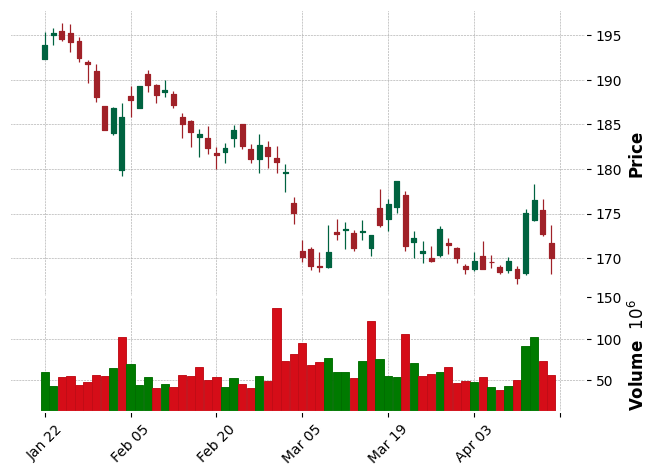

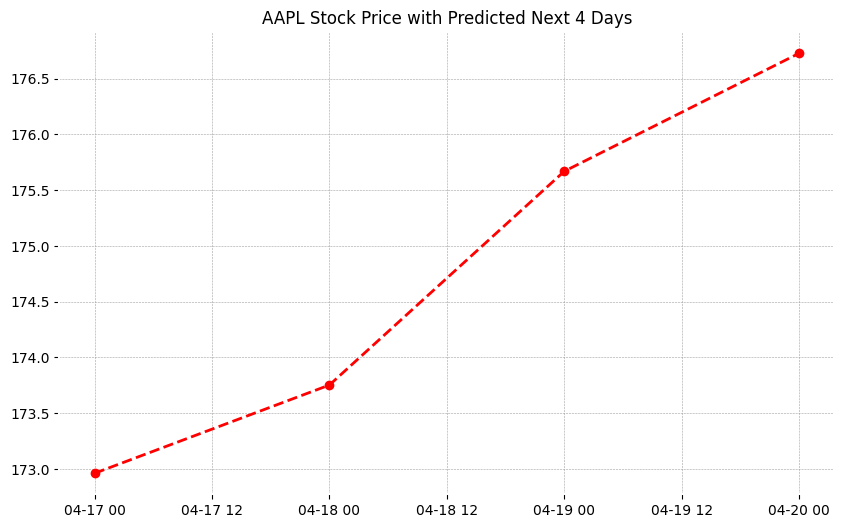

In [ ]:
!pip install mplfinance -qqq
import pandas as pd
import mplfinance as mpf
import matplotlib.dates as mpl_dates
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame with the fetched AAPL stock data
# Make sure it contains Open, High, Low, Close, and Volume columns

# Creating a list of dates for the predictions
last_date = data.index[-1]
next_day = last_date + pd.Timedelta(days=1)
prediction_dates = pd.date_range(start=next_day, periods=4)

# Assuming 'predicted_prices' is your list of predicted prices for the next 4 days
predictions_df = pd.DataFrame(index=prediction_dates, data=predicted_prices, columns=['Close'])

# Plotting the actual data with mplfinance
mpf.plot(data, type='candle', style='charles', volume=True)

# Overlaying the predicted data
plt.figure(figsize=(10,6))
plt.plot(predictions_df.index, predictions_df['Close'], linestyle='dashed', marker='o', color='red')

plt.title("AAPL Stock Price with Predicted Next 4 Days")
plt.show()

Final Visual for Predictions

[*********************100%%**********************]  1 of 1 completed

1/1 [==============================] - 0s 48ms/step


1/1 [==============================] - 0s 117ms/step


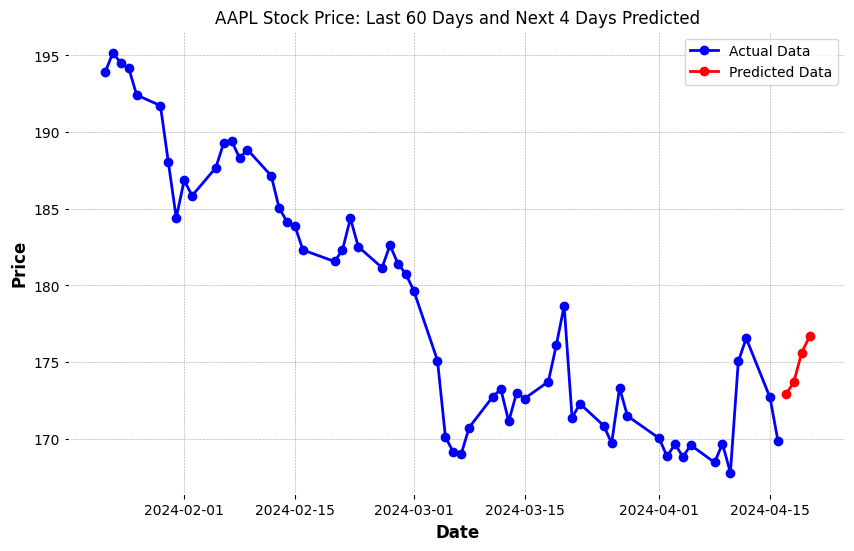

In [ ]:
import pandas as pd
import mplfinance as mpf
import matplotlib.dates as mpl_dates
import matplotlib.pyplot as plt

# Fetch the latest 60 days of AAPL stock data
data = yf.download('AAPL', period='64d', interval='1d') # Fetch 64 days to display last 60 days in the chart

# Select 'Close' price and scale it
closing_prices = data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_prices)

# Predict the next 4 days iteratively
predicted_prices = []
current_batch = scaled_data[-60:].reshape(1, 60, 1)  # Most recent 60 days

for i in range(4):  # Predicting 4 days
    next_prediction = model.predict(current_batch)
    next_prediction_reshaped = next_prediction.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:, 1:, :], next_prediction_reshaped, axis=1)
    predicted_prices.append(scaler.inverse_transform(next_prediction)[0, 0])

# Creating a list of dates for the predictions
last_date = data.index[-1]
next_day = last_date + pd.Timedelta(days=1)
prediction_dates = pd.date_range(start=next_day, periods=4)

# Adding predictions to the DataFrame
predicted_data = pd.DataFrame(index=prediction_dates, data=predicted_prices, columns=['Close'])

# Combining both actual and predicted data
combined_data = pd.concat([data['Close'], predicted_data['Close']])
combined_data = combined_data[-64:] # Last 60 days of actual data + 4 days of predictions

# Plotting the actual data
plt.figure(figsize=(10,6))
plt.plot(data.index[-60:], data['Close'][-60:], linestyle='-', marker='o', color='blue', label='Actual Data')

# Plotting the predicted data
plt.plot(prediction_dates, predicted_prices, linestyle='-', marker='o', color='red', label='Predicted Data')

plt.title("AAPL Stock Price: Last 60 Days and Next 4 Days Predicted")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


Optional for computing from any date from user input

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta

def predict_stock_price(input_date):
    # Check if the input date is a valid date format
    try:
        input_date = pd.to_datetime(input_date)
    except ValueError:
        print("Invalid Date Format. Please enter date in YYYY-MM-DD format.")
        return

    # Fetch data from yfinance
    end_date = input_date
    start_date = input_date - timedelta(days=90)  # Fetch more days to ensure we have 60 trading days
    data = yf.download('AAPL', start=start_date, end=end_date)

    if len(data) < 60:
        print("Not enough historical data to make a prediction. Try an earlier date.")
        return

    # Prepare the data
    closing_prices = data['Close'].values[-60:]  # Last 60 days
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(closing_prices.reshape(-1, 1))

    # Make predictions
    predicted_prices = []
    current_batch = scaled_data.reshape(1, 60, 1)

    for i in range(4):  # Predicting 4 days
        next_prediction = model.predict(current_batch)
        next_prediction_reshaped = next_prediction.reshape(1, 1, 1)
        current_batch = np.append(current_batch[:, 1:, :], next_prediction_reshaped, axis=1)
        predicted_prices.append(scaler.inverse_transform(next_prediction)[0, 0])

    # Output the predictions
    for i, price in enumerate(predicted_prices, 1):
        print(f"Day {i} prediction: {price}")

# Example use
user_input = input("Enter a date (YYYY-MM-DD) to predict AAPL stock for the next 4 days: ")
predict_stock_price(user_input)